<a href="https://colab.research.google.com/github/ashok-yarra/Final-Year-Project/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classifying Malicious User Content: A Natural Language Processing Approach to Identifying Spam in Social Media Comments**

# **Data Loading & Robust Date Parsing**

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# Load dataset
youtube_spam_collection = fetch_ucirepo(id=380)
df = pd.concat([youtube_spam_collection.data.features, youtube_spam_collection.data.targets], axis=1)

# Robust Date Cleaning: handles mixed formats and missing values
df['DATE'] = pd.to_datetime(df['DATE'], format='ISO8601', errors='coerce')
df['CONTENT'] = df['CONTENT'].astype(str)

print(f"Total rows: {len(df)}")
print(f"Rows with missing dates: {df['DATE'].isnull().sum()}")
df.head()

Total rows: 1956
Rows with missing dates: 245


,AUTHOR,DATE,CONTENT,CLASS
0,Julius NM,2013-11-07 06:20:48,"Huh, anyway check out this you[tube] channel: ...",1
1,adam riyati,2013-11-07 12:37:15,Hey guys check out my new channel and our firs...,1
2,Evgeny Murashkin,2013-11-08 17:34:21,just for test I have to say murdev.com,1
3,ElNino Melendez,2013-11-09 08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1
4,GsMega,2013-11-10 16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1


# **EDA**

## **Meta-Feature Analysis**

Average Metrics per Class (0=Ham, 1=Spam):
       char_count  word_count  capitals_count  punctuation_count
CLASS                                                           
0       49.644585    9.100946        3.502629           3.189274
1      137.341294   21.714428       14.471642           9.819900


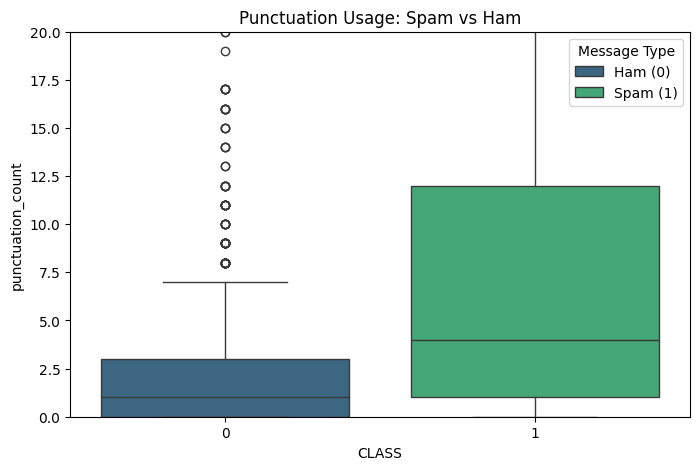

In [ ]:
# Feature Engineering for EDA
df['char_count'] = df['CONTENT'].apply(len)
df['word_count'] = df['CONTENT'].apply(lambda x: len(x.split()))
df['capitals_count'] = df['CONTENT'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['punctuation_count'] = df['CONTENT'].apply(lambda x: sum(1 for c in x if c in string.punctuation))

# Comparing Averages
metrics = df.groupby('CLASS')[['char_count', 'word_count', 'capitals_count', 'punctuation_count']].mean()
print("Average Metrics per Class (0=Ham, 1=Spam):")
print(metrics)

# Visualizing Punctuation vs Class
plt.figure(figsize=(8, 5))

# Adding 'hue' allows Seaborn to create a legend automatically
sns.boxplot(x='CLASS', y='punctuation_count', hue='CLASS', data=df, palette='viridis')

plt.title('Punctuation Usage: Spam vs Ham')
plt.ylim(0, 20)

# Customizing the legend labels for clarity
plt.legend(title='Message Type', labels=['Ham (0)', 'Spam (1)'])

plt.show()

## **Feature Correlation & Density Analysis**

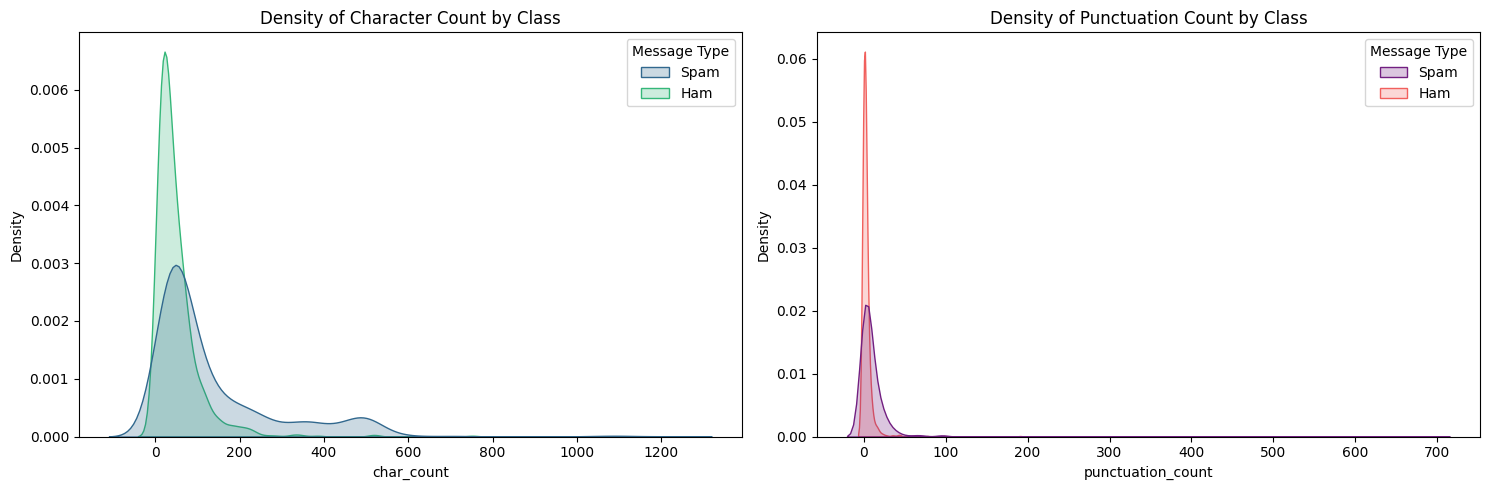

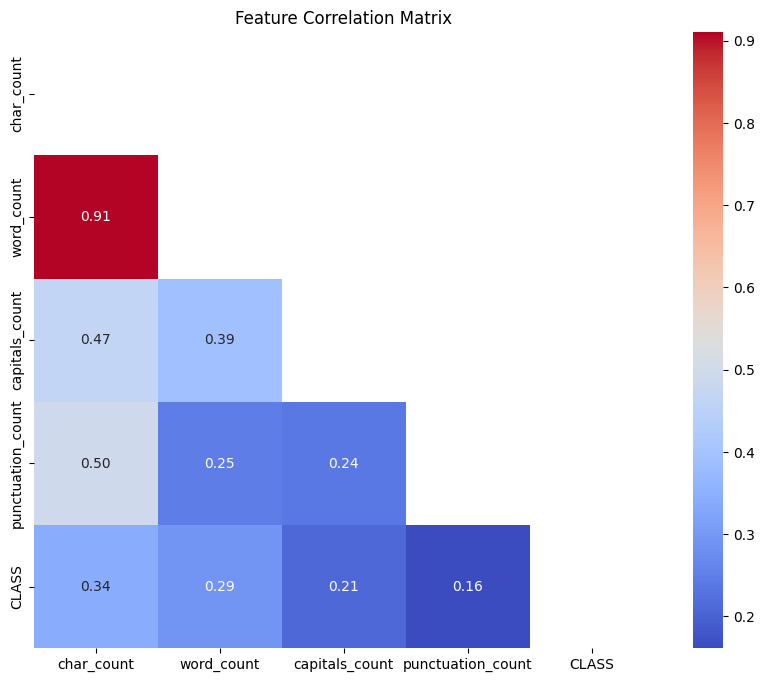

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Engineering for deeper insights
df['char_count'] = df['CONTENT'].apply(len)
df['punctuation_count'] = df['CONTENT'].apply(lambda x: sum(1 for c in x if c in string.punctuation))
df['capitals_count'] = df['CONTENT'].apply(lambda x: sum(1 for c in x if c.isupper()))

# 1. Class-wise Density Plots
# These show the 'shape' of the data for Spam vs Ham
# Create a temporary column for better labeling
df['Class_Label'] = df['CLASS'].map({0: 'Ham', 1: 'Spam'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Character Count
sns.kdeplot(data=df, x='char_count', hue='Class_Label', fill=True, ax=axes[0], palette='viridis')
axes[0].set_title('Density of Character Count by Class')
axes[0].legend_.set_title('Message Type') # Optional: rename legend title

# Plot 2: Punctuation Count
sns.kdeplot(data=df, x='punctuation_count', hue='Class_Label', fill=True, ax=axes[1], palette='magma')
axes[1].set_title('Density of Punctuation Count by Class')
axes[1].legend_.set_title('Message Type')

plt.tight_layout()
plt.show()

# 2. Correlation Heatmap (Triangular Matrix)
# Identifying which numerical features are redundant
plt.figure(figsize=(10, 8))
corr = df[['char_count', 'word_count', 'capitals_count', 'punctuation_count', 'CLASS']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

## **Bivariate Analysis: Pairplots**

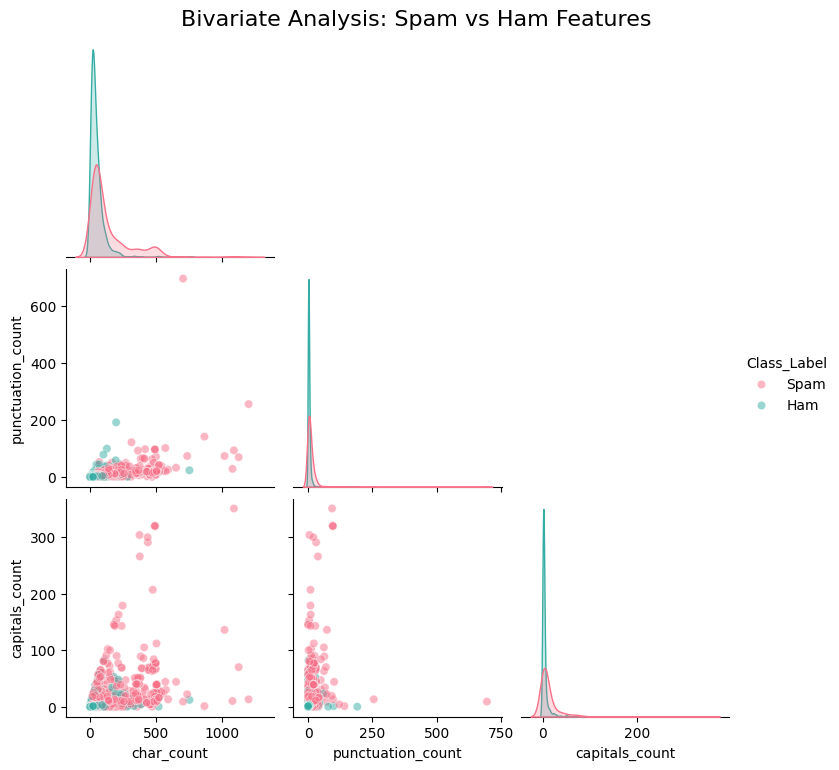

In [ ]:
# 1. First, create a descriptive label column if you haven't already
df['Class_Label'] = df['CLASS'].map({0: 'Ham', 1: 'Spam'})

# 2. Select the columns including the new string label
# Note: We exclude the numeric 'CLASS' column so it doesn't create its own row/column
plot_cols = ['char_count', 'punctuation_count', 'capitals_count', 'Class_Label']

# 3. Generate the Pairplot
g = sns.pairplot(df[plot_cols],
                 hue='Class_Label',
                 palette='husl',
                 corner=True,
                 diag_kind='kde',
                 plot_kws={'alpha': 0.5}) # Alpha helps see density where points overlap

# Adding a title and adjusting the layout
g.fig.suptitle('Bivariate Analysis: Spam vs Ham Features', y=1.02, fontsize=16)

plt.show()

# **Comprehensive Text Preprocessing**

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = nltk.stem.WordNetLemmatizer()

def clean_text_for_research(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs - very important for spam datasets
    text = re.sub(r'http\S+|www\S+|https\S+', '[URL]', text, flags=re.MULTILINE)
    # 3. Remove Special Characters/Numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 4. Tokenize & Lemmatize
    tokens = text.split()
    # Removing stopwords and words shorter than 2 characters
    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]

    return " ".join(clean_tokens)

# Apply to dataframe
df['PROCESSED_CONTENT'] = df['CONTENT'].apply(clean_text_for_research)

# Quick check on the result
print("\n--- Preprocessing Result ---")
print(f"Original: {df['CONTENT'].iloc[10]}")
print(f"Cleaned:  {df['PROCESSED_CONTENT'].iloc[10]}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...



--- Preprocessing Result ---
Original: Hey subscribe to me﻿
Cleaned:  hey subscribe


## **WordCloud**

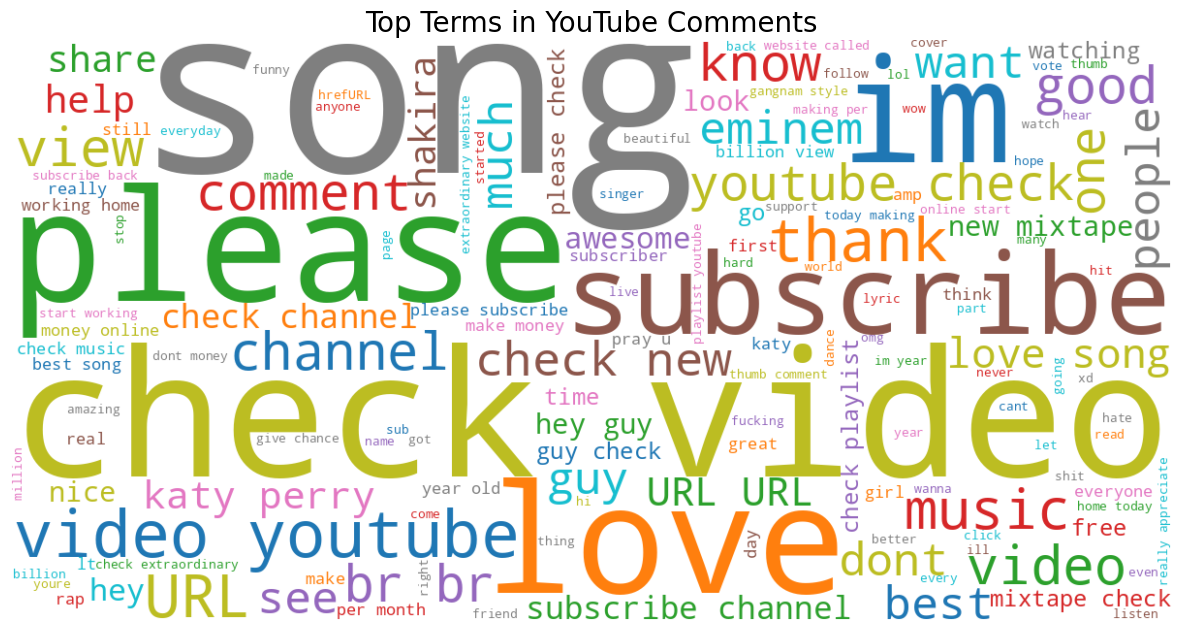

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Combine all processed text into one large string
# We use PROCESSED_CONTENT since you've already handled stopwords and lemmatization
clean_text_combined = " ".join(df['PROCESSED_CONTENT'].astype(str))

# 2. Configure the WordCloud
# Note: We set stopwords=None because you already filtered them in your function
wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='tab10',      # A colorful, distinct palette
    max_words=150,         # Limits noise
    min_font_size=10
).generate(clean_text_combined)

# 3. Plotting
plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")  # Hide the X and Y axis
plt.title("Top Terms in YouTube Comments", fontsize=20)
plt.show()

## **Correlation HeatMap after Preprocessing**

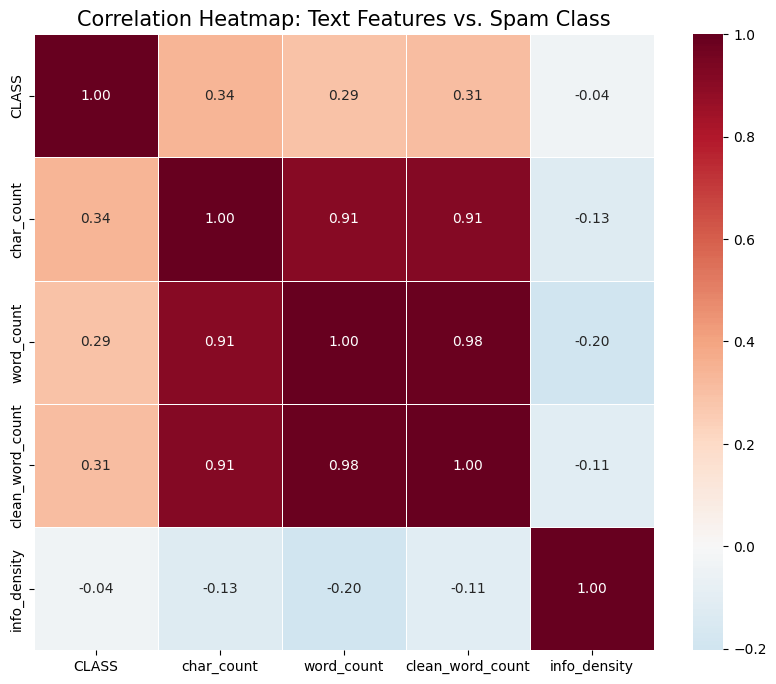

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create numerical features for correlation
df['char_count'] = df['CONTENT'].str.len()
df['word_count'] = df['CONTENT'].apply(lambda x: len(x.split()))
df['clean_word_count'] = df['PROCESSED_CONTENT'].apply(lambda x: len(x.split()))
# Proportion of "useful" words after your cleaning
df['info_density'] = df['clean_word_count'] / df['word_count']

# Select only numerical columns for the heatmap
numerical_df = df[['CLASS', 'char_count', 'word_count', 'clean_word_count', 'info_density']]
corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Text Features vs. Spam Class', fontsize=15)
plt.show()

# **Visualizing Word Importance (N-Grams)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

# Top bigrams in Spam
top_spam_bigrams = get_top_ngram(df[df['CLASS']==1]['PROCESSED_CONTENT'], 2)
print("Top 10 Spam Bigrams:", top_spam_bigrams)

Top 10 Spam Bigrams: [('check video', np.int64(140)), ('video youtube', np.int64(111)), ('check new', np.int64(63)), ('br br', np.int64(46)), ('check channel', np.int64(45)), ('subscribe channel', np.int64(43)), ('new mixtape', np.int64(39)), ('hey guy', np.int64(38)), ('check playlist', np.int64(37)), ('mixtape check', np.int64(36))]


# **Data Preparation and Splitting**
This section prepares the processed text and labels for the machine learning pipeline. The data is divided into a training set (80%) and a testing set (20%). Stratification is applied to ensure that the proportion of Spam and Ham messages remains consistent across both sets, preventing bias during the evaluation phase

In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df['PROCESSED_CONTENT']
y = df['CLASS']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1564
Testing samples: 392


# **Feature Extraction (TF-IDF Vectorization)**
Numerical representation of text is required for machine learning algorithms. The TfidfVectorizer converts the cleaned text into a matrix of TF-IDF features. This method calculates the Term Frequency-Inverse Document Frequency, which gives higher weight to words that are descriptive of a specific class (Spam) while reducing the weight of words that appear frequently across all documents.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=2500, ngram_range=(1, 2))

# Transform the text data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

Feature matrix shape: (1564, 2500)


# **Model Initialization and Training**
Three distinct models are initialized to compare different learning approaches:

Random Forest: An ensemble of decision trees that handles non-linear relationships.

Support Vector Machine (SVM): A model that finds the optimal hyperplane to separate classes in high-dimensional space.

Voting Classifier (Ensemble): A meta-classifier that combines the predictions of Random Forest, SVM, and Logistic Regression to produce a final result based on a "soft" voting logic (averaging predicted probabilities).

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Initialize individual models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(probability=True, kernel='linear', random_state=42)
lr_model = LogisticRegression()

# Create the Ensemble model
ensemble_model = VotingClassifier(
    estimators=[('rf', rf_model), ('svm', svm_model), ('lr', lr_model)],
    voting='soft'
)

# Store models in a dictionary for iteration
models = {
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Logistic Regression": lr_model,
    "Ensemble (Voting)": ensemble_model
}

## **Performance Evaluation and Metrics**
Each model is trained, and its performance is measured using several metrics. Precision indicates the accuracy of spam detections, Recall indicates the ability to find all spam messages, and the F1-Score provides a harmonic mean of both. Training and testing times are recorded to assess the computational efficiency of each algorithm.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

for name, model in models.items():
    # Measure training time
    start_train = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_train

    # Measure inference time
    start_test = time.time()
    y_pred = model.predict(X_test_tfidf)
    test_time = time.time() - start_test

    # Store metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Train Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    }

# Display results in a table
performance_df = pd.DataFrame(results).T
performance_df

,Accuracy,Precision,Recall,F1-Score,Train Time (s),Test Time (s)
Random Forest,0.959184,0.984293,0.935323,0.959184,0.6817,0.0165
SVM,0.954082,0.964467,0.945274,0.954774,0.4470,0.0225
Logistic Regression,0.936224,0.948980,0.925373,0.937028,0.0260,0.0003
Ensemble (Voting),0.956633,0.964646,0.950249,0.957393,1.1572,0.0423


## **Visualizing Confusion Matrices**
The confusion matrix provides a detailed breakdown of correct and incorrect classifications. It displays True Positives (Spam correctly identified), True Negatives (Ham correctly identified), False Positives (Ham mistaken for Spam), and False Negatives (Spam missed by the model).

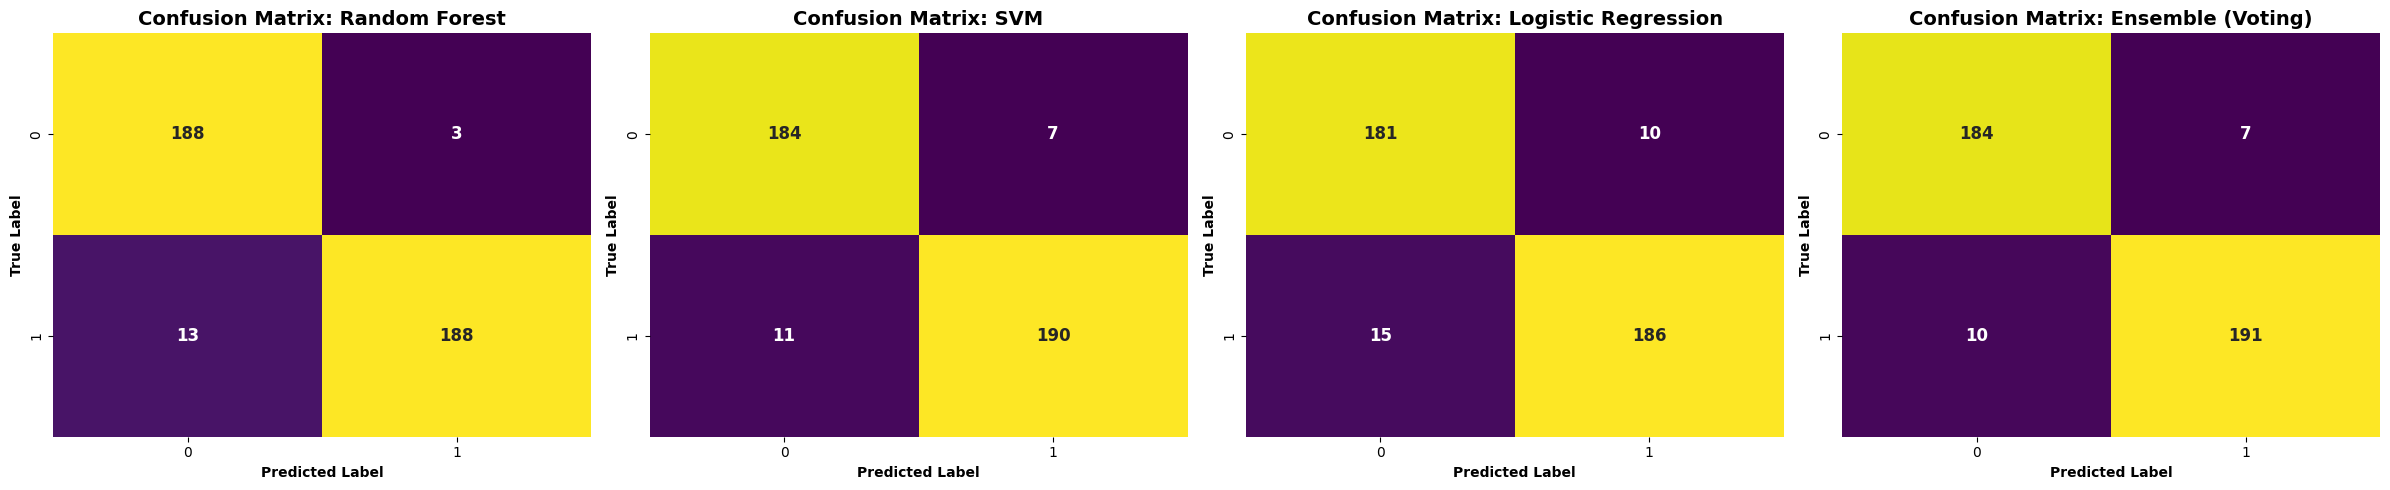

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Dynamically create subplots based on the number of models
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))

# Ensure axes is always an iterable array
if len(models) == 1:
    axes = [axes]

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)

    # Use annot_kws={'weight': 'bold'} to bold the numbers inside the matrix
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        ax=axes[i],
        cmap='viridis',
        cbar=False,
        annot_kws={"weight": "bold", "size": 12} # Bolds the text and sets size
    )

    # Optional: Bold the titles and labels for consistency
    axes[i].set_title(f'Confusion Matrix: {name}', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Predicted Label', fontweight='bold')
    axes[i].set_ylabel('True Label', fontweight='bold')

plt.tight_layout()


## **ROC Curve and AUC Analysis**
The Receiver Operating Characteristic (ROC) curve illustrates the diagnostic ability of the classifiers by plotting the True Positive Rate against the False Positive Rate at various threshold settings. The Area Under the Curve (AUC) score summarizes this performance; a score closer to 1.0 represents a near-perfect model.

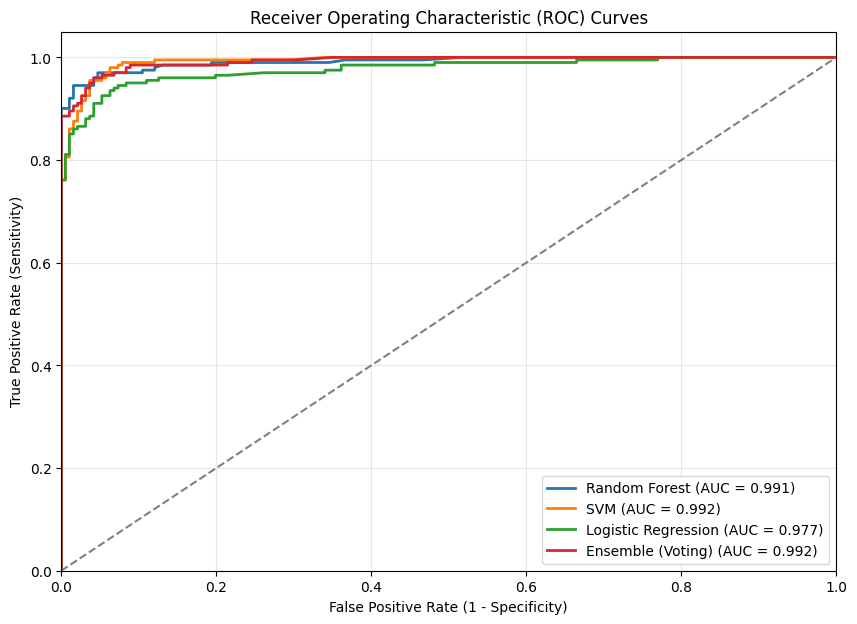

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Get predicted probabilities for the positive class (Spam)
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]

    # Calculate ROC values
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()